In [1]:
# ── STEP 1: IMPORTS ──────────────────────────────────────

import os
import numpy as np
import pandas as pd
import librosa
import tensorflow as tf
from tensorflow.keras import layers, Model
from scipy.fftpack import dct
from scipy.optimize import brentq
from scipy.interpolate import interp1d
from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

2026-06-22 03:02:55.288319: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1782097375.479502      59 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1782097375.531366      59 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1782097375.934975      59 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1782097375.935012      59 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1782097375.935014      59 computation_placer.cc:177] computation placer alr

In [2]:
# ── STEP 2: CONFIGURATION + DATA LOADING (FIXED PATHS) ──────────────

# -----------------------------------------------------------
# 2A. CONFIGURATION
# -----------------------------------------------------------

SAMPLE_RATE  = 16000
MAX_DURATION = 4.0
MAX_SAMPLES  = int(SAMPLE_RATE * MAX_DURATION)

N_MELS       = 80
N_FFT        = 512
HOP_LENGTH   = 160
FMAX         = 8000
N_LFCC       = 60

BATCH_SIZE   = 32
SEED         = 42

# ── FIXED: correct path from your Kaggle dataset panel ──────
BASE_DIR = "/kaggle/input/datasets/awsaf49/asvpoof-2019-dataset"

# ── FIXED: your dataset has an extra nested folder LA/LA and PA/PA
LA_DIR   = os.path.join(BASE_DIR, "LA", "LA")
PA_DIR   = os.path.join(BASE_DIR, "PA", "PA")

print("Configuration done.")
print("MAX_SAMPLES per file:", MAX_SAMPLES, "(= 4 seconds at 16kHz)")
print("LA_DIR:", LA_DIR)
print("PA_DIR:", PA_DIR)

# quick check — confirm folders exist
for d in [LA_DIR, PA_DIR]:
    if os.path.exists(d):
        print("EXISTS : " + d)
    else:
        print("MISSING: " + d)

Configuration done.
MAX_SAMPLES per file: 64000 (= 4 seconds at 16kHz)
LA_DIR: /kaggle/input/datasets/awsaf49/asvpoof-2019-dataset/LA/LA
PA_DIR: /kaggle/input/datasets/awsaf49/asvpoof-2019-dataset/PA/PA
EXISTS : /kaggle/input/datasets/awsaf49/asvpoof-2019-dataset/LA/LA
EXISTS : /kaggle/input/datasets/awsaf49/asvpoof-2019-dataset/PA/PA


In [3]:
# -----------------------------------------------------------
# 2B. PROTOCOL PARSER — unchanged, works as before
# -----------------------------------------------------------

def parse_protocol(protocol_path):
    rows = []
    with open(protocol_path, "r") as f:
        for line in f:
            parts = line.strip().split()
            rows.append({
                "speaker_id"  : parts[0],
                "file_id"     : parts[1],
                "attack_type" : parts[3],
                "label"       : parts[4],
                "label_int"   : 0 if parts[4] == "bonafide" else 1
            })
    return pd.DataFrame(rows)


# -----------------------------------------------------------
# 2C. LOAD PROTOCOLS — FIXED folder names to match your tree
# -----------------------------------------------------------

def load_protocols(subset="LA"):
    """
    Fixed to match your exact Kaggle folder structure:

    LA/LA/
        ASVspoof2019_LA_cm_protocols/
            ASVspoof2019.LA.cm.train.trn.txt
            ASVspoof2019.LA.cm.dev.trl.txt
            ASVspoof2019.LA.cm.eval.trl.txt
        ASVspoof2019_LA_train/
        ASVspoof2019_LA_dev/
        ASVspoof2019_LA_eval/
    """
    base      = LA_DIR if subset == "LA" else PA_DIR
    proto_dir = os.path.join(
        base,
        "ASVspoof2019_" + subset + "_cm_protocols"
    )

    splits = {
        "train" : "ASVspoof2019." + subset + ".cm.train.trn.txt",
        "dev"   : "ASVspoof2019." + subset + ".cm.dev.trl.txt",
        "eval"  : "ASVspoof2019." + subset + ".cm.eval.trl.txt",
    }

    protocols = {}

    for split, fname in splits.items():
        path = os.path.join(proto_dir, fname)

        if os.path.exists(path):
            df = parse_protocol(path)
            protocols[split] = df
            n_bonafide = (df.label == "bonafide").sum()
            n_spoof    = (df.label == "spoof").sum()
            print(subset + " | " + split
                  + " | total: "    + str(len(df))
                  + " | bonafide: " + str(n_bonafide)
                  + " | spoof: "    + str(n_spoof))
        else:
            print("NOT FOUND: " + path)

    return protocols

# -----------------------------------------------------------
# 2D. BUILD FILE LISTS — FIXED audio folder paths
# -----------------------------------------------------------

def build_file_list(df, audio_dir):
    """
    Matches file_id from protocol to actual .flac file on disk.

    Your folder structure from the Kaggle panel:
        ASVspoof2019_LA_train/   ← audio files directly inside
        ASVspoof2019_LA_dev/
        ASVspoof2019_LA_eval/

    NOTE: some Kaggle versions of this dataset store .flac files
    directly in the folder (no 'flac' subfolder).
    This function tries both and uses whichever exists.
    """
    file_paths = []
    labels     = []
    missing    = 0

    for _, row in df.iterrows():
        fid = row["file_id"]

        # try path WITH flac subfolder first
        path_with_sub = os.path.join(audio_dir, "flac", fid + ".flac")

        # try path WITHOUT flac subfolder (direct)
        path_direct   = os.path.join(audio_dir, fid + ".flac")

        if os.path.exists(path_with_sub):
            file_paths.append(path_with_sub)
            labels.append(row["label_int"])

        elif os.path.exists(path_direct):
            file_paths.append(path_direct)
            labels.append(row["label_int"])

        else:
            missing += 1

    if missing > 0:
        print("WARNING: " + str(missing) + " files not found on disk")

    return np.array(file_paths), np.array(labels, dtype=np.int32)


def compute_class_weights(labels):
    n_total    = len(labels)
    n_bonafide = (labels == 0).sum()
    n_spoof    = (labels == 1).sum()
    w_bonafide = n_total / (2.0 * n_bonafide)
    w_spoof    = n_total / (2.0 * n_spoof)
    print("Class weight — bonafide: " + str(round(w_bonafide, 3))
          + " | spoof: " + str(round(w_spoof, 3)))
    return {0: w_bonafide, 1: w_spoof}


# -----------------------------------------------------------
# 2E. RUN IT — with your corrected folder names
# -----------------------------------------------------------

print("Loading LA protocols...")
la_protocols = load_protocols("LA")

# ── FIXED: audio folder paths using your exact folder names ──
train_audio_dir = os.path.join(LA_DIR, "ASVspoof2019_LA_train")
dev_audio_dir   = os.path.join(LA_DIR, "ASVspoof2019_LA_dev")
eval_audio_dir  = os.path.join(LA_DIR, "ASVspoof2019_LA_eval")

print("\nBuilding file lists...")
train_paths, train_labels = build_file_list(
    la_protocols["train"], train_audio_dir
)
dev_paths, dev_labels = build_file_list(
    la_protocols["dev"], dev_audio_dir
)
eval_paths, eval_labels = build_file_list(
    la_protocols["eval"], eval_audio_dir
)

print("\nTrain files found : " + str(len(train_paths)))
print("Dev   files found : " + str(len(dev_paths)))
print("Eval  files found : " + str(len(eval_labels)))

# compute class weights for training
class_weights = compute_class_weights(train_labels)

Loading LA protocols...
LA | train | total: 25380 | bonafide: 2580 | spoof: 22800
LA | dev | total: 24844 | bonafide: 2548 | spoof: 22296
LA | eval | total: 71237 | bonafide: 7355 | spoof: 63882

Building file lists...

Train files found : 25380
Dev   files found : 24844
Eval  files found : 71237
Class weight — bonafide: 4.919 | spoof: 0.557


In [4]:
import librosa
import numpy as np

In [5]:
def load_audio(path):

    audio, sr = librosa.load(
        path,
        sr=SAMPLE_RATE
    )

    # normalize

    audio = audio / (
        np.max(np.abs(audio)) + 1e-8
    )

    # pad if short

    if len(audio) < MAX_SAMPLES:

        pad_length = (
            MAX_SAMPLES - len(audio)
        )

        audio = np.pad(
            audio,
            (0, pad_length)
        )

    # crop if long

    else:

        audio = audio[:MAX_SAMPLES]

    return audio.astype(np.float32)

In [6]:
def extract_log_mel(audio):

    mel = librosa.feature.melspectrogram(
        y=audio,
        sr=SAMPLE_RATE,
        n_fft=N_FFT,
        hop_length=HOP_LENGTH,
        n_mels=N_MELS,
        fmax=FMAX
    )

    log_mel = librosa.power_to_db(
        mel,
        ref=np.max
    )

    return log_mel.astype(np.float32)

In [7]:
sample_audio = load_audio(
    train_paths[0]
)

print(sample_audio.shape)

(64000,)


In [8]:
sample_feature = extract_log_mel(
    sample_audio
)

print(sample_feature.shape)

(80, 401)


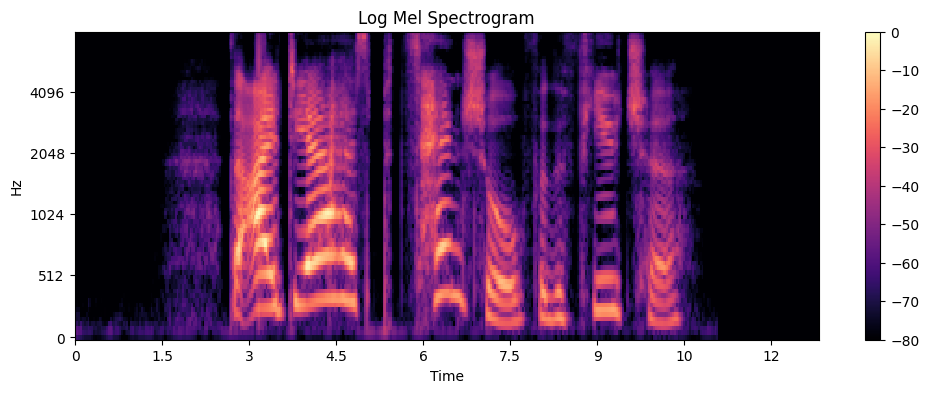

In [9]:
import matplotlib.pyplot as plt
import librosa.display

plt.figure(figsize=(12,4))

librosa.display.specshow(
    sample_feature,
    sr=SAMPLE_RATE,
    x_axis="time",
    y_axis="mel"
)

plt.colorbar()

plt.title(
    "Log Mel Spectrogram"
)

plt.show()

In [10]:
X_train = []
y_train = []

for i in range(100):

    audio = load_audio(
        train_paths[i]
    )

    feature = extract_log_mel(
        audio
    )

    X_train.append(feature)
    y_train.append(
        train_labels[i]
    )

X_train = np.array(X_train)
y_train = np.array(y_train)

print(X_train.shape)
print(y_train.shape)

(100, 80, 401)
(100,)


In [12]:
def process_file(path):

    audio = load_audio(path)

    feature = extract_log_mel(audio)

    feature = np.expand_dims(
        feature,
        axis=-1
    )

    return feature.astype(np.float32)

In [13]:
x = process_file(
    train_paths[0]
)

print(x.shape)

(80, 401, 1)


In [14]:
def spec_augment(feature):

    feature = tf.convert_to_tensor(
        feature
    )

    # frequency masking

    freq_mask = tf.random.uniform(
        [],
        0,
        10,
        dtype=tf.int32
    )

    freq_start = tf.random.uniform(
        [],
        0,
        80-freq_mask,
        dtype=tf.int32
    )

    mask = tf.ones_like(feature)

    mask = tf.tensor_scatter_nd_update(
        mask,
        indices=tf.reshape(
            tf.range(
                freq_start,
                freq_start+freq_mask
            ),
            (-1,1)
        ),
        updates=tf.zeros(freq_mask)
    )

    feature = feature * mask[:,:,None]

    return feature

In [41]:
from sklearn.utils import shuffle

train_paths_shuf, train_labels_shuf = shuffle(
    train_paths,
    train_labels,
    random_state=42
)

dev_paths_shuf, dev_labels_shuf = shuffle(
    dev_paths,
    dev_labels,
    random_state=42
)

In [42]:
N = 2000
N_VAL = 500

train_paths_small = train_paths_shuf[:N]
train_labels_small = train_labels_shuf[:N]

dev_paths_small = dev_paths_shuf[:N_VAL]
dev_labels_small = dev_labels_shuf[:N_VAL]

In [43]:
print(np.bincount(train_labels_small))
print(np.bincount(dev_labels_small))

[ 201 1799]
[ 45 455]


In [44]:
X_train = []
y_train = []

for path,label in zip(
    train_paths_small,
    train_labels_small
):
    feat = process_file(path)

    X_train.append(feat)
    y_train.append(label)

X_train = np.array(X_train)

y_train = np.array(y_train)

print(X_train.shape)
print(y_train.shape)

(2000, 80, 401, 1)
(2000,)


In [47]:

X_val = []
y_val = []

for path, label in zip(
    dev_paths_small,
    dev_labels_small
):

    feat = process_file(path)

    X_val.append(feat)
    y_val.append(label)

X_val = np.array(X_val)
y_val = np.array(y_val)

print(X_val.shape)
print(y_val.shape)

(500, 80, 401, 1)
(500,)


In [48]:
print(np.bincount(y_train))
print(np.bincount(y_val))

[ 201 1799]
[ 45 455]


In [49]:
mean = X_train.mean()

std = X_train.std()

X_train = (
    X_train - mean
) / (std + 1e-8)

X_val = (
    X_val - mean
) / (std + 1e-8)

In [50]:
print(X_train.mean())
print(X_train.std())

2.7762624e-08
1.0


In [54]:
from tensorflow.keras.layers import *
from tensorflow.keras.models import Model

In [55]:
inputs = Input(
    shape=(80,401,1)
)

x = Conv2D(
    32,
    3,
    padding="same",
    activation="relu"
)(inputs)

x = BatchNormalization()(x)

x = MaxPooling2D()(x)

x = Conv2D(
    64,
    3,
    padding="same",
    activation="relu"
)(x)

x = BatchNormalization()(x)

x = MaxPooling2D()(x)

x = Conv2D(
    128,
    3,
    padding="same",
    activation="relu"
)(x)

x = BatchNormalization()(x)

x = GlobalAveragePooling2D()(x)

x = Dense(
    128,
    activation="relu"
)(x)

x = Dropout(0.3)(x)

outputs = Dense(
    1,
    activation="sigmoid"
)(x)

model = Model(
    inputs,
    outputs
)

model.summary()

Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 80, 401, 1)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 80, 401, 32)    │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 80, 401, 32)    │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 40, 200, 32)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 40, 200, 64)    │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_10          │ (None, 40, 200, 64)    │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 20, 100, 64)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 20, 100, 128)   │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_11          │ (None, 20, 100, 128)   │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_3      │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 110,209 (430.50 KB)

 Trainable params: 109,761 (428.75 KB)

 Non-trainable params: 448 (1.75 KB)

In [57]:
X_train.shape


(2000, 80, 401, 1)

In [58]:
X_val.shape

(500, 80, 401, 1)

In [59]:
model.summary()

Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 80, 401, 1)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 80, 401, 32)    │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 80, 401, 32)    │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 40, 200, 32)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 40, 200, 64)    │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_10          │ (None, 40, 200, 64)    │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 20, 100, 64)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 20, 100, 128)   │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_11          │ (None, 20, 100, 128)   │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_3      │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 110,209 (430.50 KB)

 Trainable params: 109,761 (428.75 KB)

 Non-trainable params: 448 (1.75 KB)

In [65]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

classes = np.unique(y_train)

weights = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=y_train
)

class_weights = {
    0: weights[0],
    1: weights[1]
}

print(class_weights)

{0: np.float64(4.975124378109452), 1: np.float64(0.5558643690939411)}


In [70]:
history = model.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=20,
    batch_size=32,
    callbacks=callbacks,
    class_weight=class_weights
)

Epoch 1/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 9s 75ms/step - accuracy: 0.7445 - loss: 0.5312 - val_accuracy: 0.9100 - val_loss: 0.5909 - learning_rate: 0.0010
Epoch 2/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - accuracy: 0.7815 - loss: 0.4462 - val_accuracy: 0.9100 - val_loss: 0.9305 - learning_rate: 0.0010
Epoch 3/20
61/63 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.7905 - loss: 0.3777
Epoch 3: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - accuracy: 0.7910 - loss: 0.3834 - val_accuracy: 0.9100 - val_loss: 1.1472 - learning_rate: 0.0010
Epoch 4/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - accuracy: 0.8520 - loss: 0.3039 - val_accuracy: 0.9100 - val_loss: 0.7849 - learning_rate: 5.0000e-04
Epoch 5/20
61/63 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.8692 - loss: 0.2630
Epoch 5: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - accuracy: 0.8685 - loss: 0.2562 - val_a

In [68]:
from tensorflow.keras.optimizers import Adam

model.compile(
    optimizer=Adam(1e-3),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

In [69]:
from tensorflow.keras.callbacks import *

callbacks = [

    EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True
    ),

    ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=2,
        verbose=1
    )
]

In [62]:
history = model.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=20,
    batch_size=32,
    callbacks=callbacks,
    class_weight=class_weights
)

Epoch 1/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 9s 76ms/step - accuracy: 0.8945 - loss: 0.3430 - val_accuracy: 0.9100 - val_loss: 0.3188 - learning_rate: 0.0010
Epoch 2/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - accuracy: 0.9010 - loss: 0.2890 - val_accuracy: 0.9100 - val_loss: 0.6544 - learning_rate: 0.0010
Epoch 3/20
61/63 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.8823 - loss: 0.3043
Epoch 3: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - accuracy: 0.8985 - loss: 0.2635 - val_accuracy: 0.9100 - val_loss: 0.9277 - learning_rate: 0.0010
Epoch 4/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - accuracy: 0.9100 - loss: 0.2104 - val_accuracy: 0.9100 - val_loss: 0.9531 - learning_rate: 5.0000e-04
Epoch 5/20
61/63 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.9181 - loss: 0.2126
Epoch 5: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - accuracy: 0.9185 - loss: 0.1951 - val_a

In [71]:
val_loss, val_acc = model.evaluate(
    X_val,
    y_val,
    verbose=0
)

print("Validation Accuracy:", val_acc)

Validation Accuracy: 0.9620000123977661


In [72]:
from sklearn.metrics import (
    confusion_matrix,
    classification_report
)

pred_probs = model.predict(X_val)

preds = (
    pred_probs > 0.5
).astype(int)

print(
    classification_report(
        y_val,
        preds
    )
)

16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step
              precision    recall  f1-score   support

           0       0.72      0.96      0.82        45
           1       1.00      0.96      0.98       455

    accuracy                           0.96       500
   macro avg       0.86      0.96      0.90       500
weighted avg       0.97      0.96      0.96       500



In [74]:
from sklearn.metrics import roc_curve
from scipy.optimize import brentq
from scipy.interpolate import interp1d

In [76]:
scores = pred_probs.ravel()

fpr, tpr, thresholds = roc_curve(
    y_val,
    scores
)

eer = brentq(
    lambda x: 1. - x - interp1d(
        fpr,
        tpr
    )(x),
    0.,
    1.
)

print(
    "EER = {:.2f}%".format(
        eer * 100
    )
)

EER = 4.44%


In [95]:
import tensorflow as tf

tf.keras.backend.clear_session()

In [96]:
from tensorflow.keras.layers import *

In [97]:
def transformer_block(x,
                      head_size=64,
                      num_heads=4,
                      ff_dim=128,
                      dropout=0.2):

    attn = MultiHeadAttention(
        num_heads=num_heads,
        key_dim=head_size,
        dropout=dropout
    )(x, x)

    x = Add()([x, attn])

    x = LayerNormalization()(x)

    ff = Dense(
        ff_dim,
        activation="gelu"
    )(x)

    ff = Dropout(dropout)(ff)

    ff = Dense(
        x.shape[-1]
    )(ff)

    x = Add()([x, ff])

    x = LayerNormalization()(x)

    return x

In [98]:
inputs = Input(
    shape=(80,401,1)
)

x = Conv2D(
    32,
    3,
    padding="same",
    activation="relu"
)(inputs)

x = BatchNormalization()(x)

x = MaxPooling2D((2,2))(x)

x = Conv2D(
    64,
    3,
    padding="same",
    activation="relu"
)(x)

x = BatchNormalization()(x)

x = MaxPooling2D((2,2))(x)

x = Conv2D(
    128,
    3,
    padding="same",
    activation="relu"
)(x)

x = BatchNormalization()(x)

In [99]:
print(x.shape)

(None, 20, 100, 128)


In [100]:
x = AveragePooling2D(
    pool_size=(2,2)
)(x)

print("After Pool:", x.shape)

After Pool: (None, 10, 50, 128)


In [101]:
x = Reshape(
    (10*50, 128)
)(x)

print("After Reshape:", x.shape)

After Reshape: (None, 500, 128)


In [102]:
x = transformer_block(
    x,
    head_size=64,
    num_heads=4,
    ff_dim=256,
    dropout=0.2
)

print("After Transformer:", x.shape)

After Transformer: (None, 500, 128)


In [103]:
x = GlobalAveragePooling1D()(x)

print("After GAP:", x.shape)

After GAP: (None, 128)


In [104]:
x = Dense(
    256,
    activation="relu"
)(x)

x = Dropout(0.4)(x)

x = Dense(
    128,
    activation="relu"
)(x)

x = Dropout(0.3)(x)

outputs = Dense(
    1,
    activation="sigmoid"
)(x)

model = Model(
    inputs,
    outputs
)

model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 80, 401,   │          0 │ -                 │
│ (InputLayer)        │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 80, 401,   │        320 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 80, 401,   │        128 │ conv2d[0][0]      │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 40, 200,   │          0 │ batch_normalizat… │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 40, 200,   │     18,496 │ max_pooling2d[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 40, 200,   │        256 │ conv2d_1[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 20, 100,   │          0 │ batch_normalizat… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 20, 100,   │     73,856 │ max_pooling2d_1[… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 20, 100,   │        512 │ conv2d_2[0][0]    │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ average_pooling2d   │ (None, 10, 50,    │          0 │ batch_normalizat… │
│ (AveragePooling2D)  │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape (Reshape)   │ (None, 500, 128)  │          0 │ average_pooling2… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 500, 128)  │    131,968 │ reshape[0][0],    │
│ (MultiHeadAttentio… │                   │            │ reshape[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 500, 128)  │          0 │ reshape[0][0],    │
│                     │                   │            │ multi_head_atten… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalization │ (None, 500, 128)  │        256 │ add[0][0]         │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 500, 256)  │     33,024 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 500, 256)  │          0 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 500, 128)  │     32,896 │ dropout_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, 500, 128)  │          0 │ layer_normalizat… │
│                     │                   │            │ dense_1[0][0]   

 Total params: 358,017 (1.37 MB)

 Trainable params: 357,569 (1.36 MB)

 Non-trainable params: 448 (1.75 KB)

In [105]:
import tensorflow as tf

loss_fn = tf.keras.losses.BinaryFocalCrossentropy(
    gamma=2.0
)

model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=1e-4
    ),
    loss=loss_fn,
    metrics=["accuracy"]
)

In [106]:
history = model.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=20,
    batch_size=16,
    class_weight=class_weights,
    callbacks=callbacks
)

Epoch 1/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 16s 44ms/step - accuracy: 0.5715 - loss: 0.1773 - val_accuracy: 0.9100 - val_loss: 0.0959 - learning_rate: 1.0000e-04
Epoch 2/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 3s 20ms/step - accuracy: 0.6075 - loss: 0.1616 - val_accuracy: 0.9100 - val_loss: 0.1258 - learning_rate: 1.0000e-04
Epoch 3/20
124/125 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.6606 - loss: 0.1513
Epoch 3: ReduceLROnPlateau reducing learning rate to 4.999999873689376e-05.
125/125 ━━━━━━━━━━━━━━━━━━━━ 3s 20ms/step - accuracy: 0.6770 - loss: 0.1473 - val_accuracy: 0.9100 - val_loss: 0.1310 - learning_rate: 1.0000e-04
Epoch 4/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 3s 20ms/step - accuracy: 0.7290 - loss: 0.1339 - val_accuracy: 0.9120 - val_loss: 0.0786 - learning_rate: 5.0000e-05
Epoch 5/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 3s 20ms/step - accuracy: 0.7705 - loss: 0.1229 - val_accuracy: 0.9080 - val_loss: 0.0596 - learning_rate: 5.0000e-05
Epoch 6/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 3s 20ms/step - accurac

In [107]:
pred_probs = model.predict(X_val)

preds = (
    pred_probs > 0.5
).astype(int)

from sklearn.metrics import (
    classification_report,
    confusion_matrix
)

print(
    classification_report(
        y_val,
        preds
    )
)

print(
    confusion_matrix(
        y_val,
        preds
    )
)

16/16 ━━━━━━━━━━━━━━━━━━━━ 3s 90ms/step
              precision    recall  f1-score   support

           0       0.33      0.02      0.04        45
           1       0.91      1.00      0.95       455

    accuracy                           0.91       500
   macro avg       0.62      0.51      0.50       500
weighted avg       0.86      0.91      0.87       500

[[  1  44]
 [  2 453]]


In [108]:
from sklearn.metrics import roc_curve
from scipy.optimize import brentq
from scipy.interpolate import interp1d

scores = pred_probs.ravel()

fpr, tpr, thresholds = roc_curve(
    y_val,
    scores
)

eer = brentq(
    lambda x:
    1. - x - interp1d(
        fpr,
        tpr
    )(x),
    0.,
    1.
)

print(
    f"EER = {eer*100:.2f}%"
)

EER = 17.36%


In [126]:
import tensorflow as tf

tf.keras.backend.clear_session()

In [110]:
N = 8000
N_VAL = 2000

In [111]:
train_paths_small = train_paths_shuf[:N]
train_labels_small = train_labels_shuf[:N]

dev_paths_small = dev_paths_shuf[:N_VAL]
dev_labels_small = dev_labels_shuf[:N_VAL]

In [112]:
X_train = []
y_train = []

for path, label in zip(
    train_paths_small,
    train_labels_small
):

    feat = process_file(path)

    X_train.append(feat)
    y_train.append(label)

X_train = np.array(X_train)
y_train = np.array(y_train)

print(X_train.shape)

(8000, 80, 401, 1)


In [113]:
X_val = []
y_val = []

for path, label in zip(
    dev_paths_small,
    dev_labels_small
):

    feat = process_file(path)

    X_val.append(feat)
    y_val.append(label)

X_val = np.array(X_val)
y_val = np.array(y_val)

print(X_val.shape)

(2000, 80, 401, 1)


In [114]:
mean = X_train.mean()
std = X_train.std()

X_train = (
    X_train - mean
) / (std + 1e-8)

X_val = (
    X_val - mean
) / (std + 1e-8)

In [115]:
print(np.bincount(y_train))
print(np.bincount(y_val))

[ 786 7214]
[ 197 1803]


In [116]:
inputs = Input(
    shape=(80,401,1)
)

x = Conv2D(
    32,
    3,
    padding="same",
    activation="relu"
)(inputs)

x = BatchNormalization()(x)

x = MaxPooling2D()(x)

x = Conv2D(
    64,
    3,
    padding="same",
    activation="relu"
)(x)

x = BatchNormalization()(x)

x = MaxPooling2D()(x)

x = Conv2D(
    128,
    3,
    padding="same",
    activation="relu"
)(x)

x = BatchNormalization()(x)

x = GlobalAveragePooling2D()(x)

x = Dense(
    128,
    activation="relu"
)(x)

x = Dropout(0.3)(x)

outputs = Dense(
    1,
    activation="sigmoid"
)(x)

model = Model(
    inputs,
    outputs
)

model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 80, 401, 1)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 80, 401, 32)    │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 80, 401, 32)    │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 40, 200, 32)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 40, 200, 64)    │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 40, 200, 64)    │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 20, 100, 64)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 20, 100, 128)   │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 20, 100, 128)   │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 110,209 (430.50 KB)

 Trainable params: 109,761 (428.75 KB)

 Non-trainable params: 448 (1.75 KB)

In [117]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=1e-4
    ),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

In [118]:
callbacks = [

    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=7,
        restore_best_weights=True
    ),

    tf.keras.callbacks.ModelCheckpoint(
        "best_cnn.keras",
        save_best_only=True
    )
]

In [119]:
from sklearn.utils.class_weight import compute_class_weight

classes = np.unique(y_train)

weights = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=y_train
)

class_weights = {
    0: weights[0],
    1: weights[1]
}

print(class_weights)

{0: np.float64(5.089058524173028), 1: np.float64(0.5544774050457444)}


In [120]:
history = model.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=30,
    batch_size=32,
    class_weight=class_weights,
    callbacks=callbacks
)

Epoch 1/30
250/250 ━━━━━━━━━━━━━━━━━━━━ 13s 30ms/step - accuracy: 0.7256 - loss: 0.5994 - val_accuracy: 0.9015 - val_loss: 0.3145
Epoch 2/30
250/250 ━━━━━━━━━━━━━━━━━━━━ 6s 23ms/step - accuracy: 0.7746 - loss: 0.4616 - val_accuracy: 0.9015 - val_loss: 0.2919
Epoch 3/30
250/250 ━━━━━━━━━━━━━━━━━━━━ 6s 23ms/step - accuracy: 0.8089 - loss: 0.3874 - val_accuracy: 0.8705 - val_loss: 0.2912
Epoch 4/30
250/250 ━━━━━━━━━━━━━━━━━━━━ 6s 23ms/step - accuracy: 0.8378 - loss: 0.3308 - val_accuracy: 0.8865 - val_loss: 0.2771
Epoch 5/30
250/250 ━━━━━━━━━━━━━━━━━━━━ 6s 23ms/step - accuracy: 0.8646 - loss: 0.2808 - val_accuracy: 0.9020 - val_loss: 0.2353
Epoch 6/30
250/250 ━━━━━━━━━━━━━━━━━━━━ 6s 23ms/step - accuracy: 0.8891 - loss: 0.2392 - val_accuracy: 0.6935 - val_loss: 0.5949
Epoch 7/30
250/250 ━━━━━━━━━━━━━━━━━━━━ 6s 22ms/step - accuracy: 0.9121 - loss: 0.1983 - val_accuracy: 0.5550 - val_loss: 0.9432
Epoch 8/30
250/250 ━━━━━━━━━━━━━━━━━━━━ 6s 22ms/step - accuracy: 0.9214 - loss: 0.1786 - val_acc

In [121]:
pred_probs = model.predict(X_val)

preds = (
    pred_probs > 0.5
).astype(int)

print(
    classification_report(
        y_val,
        preds
    )
)

63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step
              precision    recall  f1-score   support

           0       0.96      0.96      0.96       197
           1       1.00      1.00      1.00      1803

    accuracy                           0.99      2000
   macro avg       0.98      0.98      0.98      2000
weighted avg       0.99      0.99      0.99      2000



In [122]:
scores = pred_probs.ravel()

fpr, tpr, _ = roc_curve(
    y_val,
    scores
)

eer = brentq(
    lambda x:
    1. - x - interp1d(
        fpr,
        tpr
    )(x),
    0.,
    1.
)

print(
    f"EER = {eer*100:.2f}%"
)

EER = 1.05%


In [123]:
model.save(
    "cnn_logmel_baseline.keras"
)

In [124]:
np.save(
    "train_mean.npy",
    mean
)

np.save(
    "train_std.npy",
    std
)

In [125]:
!pip install -q spafe

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 94.0/94.0 kB 3.2 MB/s eta 0:00:00


In [127]:
from spafe.features.lfcc import lfcc
import numpy as np

In [145]:
def extract_lfcc(audio):

    feat = lfcc(
        sig=audio,
        fs=SAMPLE_RATE,
        num_ceps=30,
        nfilts=80,
        nfft=512,
        low_freq=0,
        high_freq=8000
    )

    return feat.astype(np.float32)

In [146]:
audio = load_audio(train_paths[0])

lfcc_feature = extract_lfcc(audio)

print(lfcc_feature.shape)

(398, 30)


In [147]:
def process_lfcc(path):

    audio = load_audio(path)

    feat = extract_lfcc(audio)

    target_frames = 401

    if feat.shape[0] < target_frames:

        feat = np.pad(
            feat,
            ((0, target_frames-feat.shape[0]), (0,0))
        )

    else:

        feat = feat[:target_frames]

    feat = feat.T

    feat = np.expand_dims(
        feat,
        axis=-1
    )

    return feat.astype(np.float32)

In [148]:
print(
    process_lfcc(
        train_paths[0]
    ).shape
)

(30, 401, 1)


In [149]:
num_ceps = 30
nfilts = 70

In [150]:
lfcc_feature = extract_lfcc(audio)
print(lfcc_feature.shape)

x = process_lfcc(train_paths[0])
print(x.shape)

(398, 30)
(30, 401, 1)


In [151]:
X_train_lfcc = []
y_train_lfcc = []

for path, label in zip(
    train_paths_small,
    train_labels_small
):

    feat = process_lfcc(path)

    X_train_lfcc.append(feat)
    y_train_lfcc.append(label)

X_train_lfcc = np.array(X_train_lfcc)
y_train_lfcc = np.array(y_train_lfcc)

print(X_train_lfcc.shape)

(8000, 30, 401, 1)


In [152]:
X_val_lfcc = []
y_val_lfcc = []

for path, label in zip(
    dev_paths_small,
    dev_labels_small
):

    feat = process_lfcc(path)

    X_val_lfcc.append(feat)
    y_val_lfcc.append(label)

X_val_lfcc = np.array(X_val_lfcc)
y_val_lfcc = np.array(y_val_lfcc)

print(X_val_lfcc.shape)

(2000, 30, 401, 1)


In [153]:
mean_lfcc = X_train_lfcc.mean()
std_lfcc = X_train_lfcc.std()

X_train_lfcc = (
    X_train_lfcc - mean_lfcc
) / (std_lfcc + 1e-8)

X_val_lfcc = (
    X_val_lfcc - mean_lfcc
) / (std_lfcc + 1e-8)

In [157]:
from tensorflow.keras.layers import *
from tensorflow.keras.models import Model

inputs = Input(
    shape=(30,401,1)
)

x = Conv2D(
    32,
    3,
    padding="same",
    activation="relu"
)(inputs)

x = BatchNormalization()(x)

x = MaxPooling2D()(x)

x = Conv2D(
    64,
    3,
    padding="same",
    activation="relu"
)(x)

x = BatchNormalization()(x)

x = MaxPooling2D()(x)

x = Conv2D(
    128,
    3,
    padding="same",
    activation="relu"
)(x)

x = BatchNormalization()(x)

x = GlobalAveragePooling2D()(x)

x = Dense(
    128,
    activation="relu"
)(x)

x = Dropout(0.3)(x)

outputs = Dense(
    1,
    activation="sigmoid"
)(x)

lfcc_model = Model(
    inputs,
    outputs
)

lfcc_model.summary()

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 30, 401, 1)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 30, 401, 32)    │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 30, 401, 32)    │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 15, 200, 32)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 15, 200, 64)    │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 15, 200, 64)    │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 7, 100, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 7, 100, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 7, 100, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_2      │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 110,209 (430.50 KB)

 Trainable params: 109,761 (428.75 KB)

 Non-trainable params: 448 (1.75 KB)

In [158]:
lfcc_model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=1e-4
    ),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

In [161]:
history = lfcc_model.fit(
    X_train_lfcc,
    y_train_lfcc,
    validation_data=(
        X_val_lfcc,
        y_val_lfcc
    ),
    epochs=5,
    batch_size=32,
    class_weight=class_weights,
    callbacks=callbacks
)

Epoch 1/5
250/250 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - accuracy: 0.9958 - loss: 0.0139 - val_accuracy: 0.9660 - val_loss: 0.0901
Epoch 2/5
250/250 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.9971 - loss: 0.0092 - val_accuracy: 0.9985 - val_loss: 0.0037
Epoch 3/5
250/250 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.9966 - loss: 0.0112 - val_accuracy: 0.7970 - val_loss: 0.6208
Epoch 4/5
250/250 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.9980 - loss: 0.0057 - val_accuracy: 0.9935 - val_loss: 0.0230
Epoch 5/5
250/250 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.9971 - loss: 0.0105 - val_accuracy: 0.9940 - val_loss: 0.0181


In [162]:
pred_probs = lfcc_model.predict(
    X_val_lfcc
)

preds = (
    pred_probs > 0.5
).astype(int)

from sklearn.metrics import (
    classification_report,
    confusion_matrix
)

print(
    classification_report(
        y_val_lfcc,
        preds
    )
)

print(
    confusion_matrix(
        y_val_lfcc,
        preds
    )
)

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
              precision    recall  f1-score   support

           0       0.98      1.00      0.99       197
           1       1.00      1.00      1.00      1803

    accuracy                           1.00      2000
   macro avg       0.99      1.00      1.00      2000
weighted avg       1.00      1.00      1.00      2000

[[ 197    0]
 [   3 1800]]


In [163]:
from sklearn.metrics import roc_curve
from scipy.optimize import brentq
from scipy.interpolate import interp1d

scores = pred_probs.ravel()

fpr, tpr, _ = roc_curve(
    y_val_lfcc,
    scores
)

eer = brentq(
    lambda x:
    1. - x - interp1d(
        fpr,
        tpr
    )(x),
    0.,
    1.
)

print(
    f"EER = {eer*100:.2f}%"
)

EER = 0.00%


In [164]:
scores = pred_probs.reshape(-1)

print(scores.min())
print(scores.max())

5.0194413e-09
1.0


In [165]:
from sklearn.metrics import roc_curve

fpr, tpr, thresholds = roc_curve(
    y_val_lfcc,
    scores
)

print("FPR length:", len(fpr))
print("TPR length:", len(tpr))

FPR length: 290
TPR length: 290


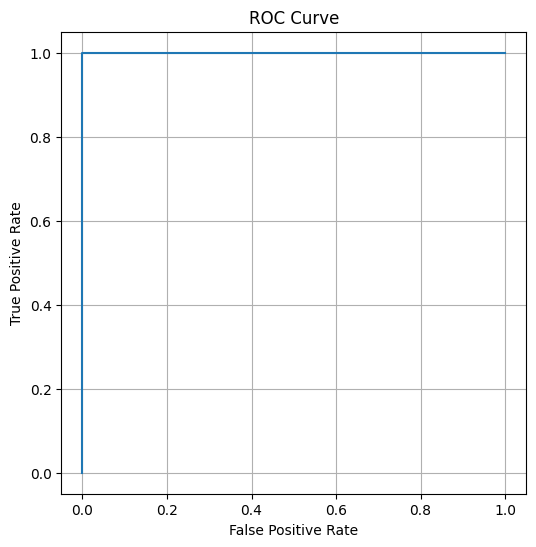

In [166]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,6))

plt.plot(fpr, tpr)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")

plt.grid(True)

plt.show()

In [169]:
from sklearn.metrics import roc_curve, auc

scores = pred_probs.ravel()

fpr, tpr, thresholds = roc_curve(
    y_val_lfcc,
    scores
)

print("AUC =", auc(fpr, tpr))

print("FPR:", fpr[:10])
print("TPR:", tpr[:10])

AUC = 1.0
FPR: [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
TPR: [0.         0.03327787 0.06211869 0.07542984 0.08485857 0.08763172
 0.09761509 0.10981697 0.11647255 0.1192457 ]


In [170]:
print(scores.min())
print(scores.max())

5.0194413e-09
1.0


In [168]:
print(np.bincount(y_train_lfcc))
print(np.bincount(y_val_lfcc))

[ 786 7214]
[ 197 1803]


In [171]:
print(np.unique(preds, return_counts=True))

(array([0, 1]), array([ 200, 1800]))


In [174]:
from sklearn.metrics import roc_curve
import numpy as np

fpr, tpr, thresholds = roc_curve(
    y_val_lfcc,
    scores
)

fnr = 1 - tpr

eer_idx = np.nanargmin(
    np.absolute(fnr - fpr)
)

eer = max(
    fpr[eer_idx],
    fnr[eer_idx]
)

print(f"EER = {eer*100:.4f}%")

EER = 0.0000%


In [ ]:
X_eval_lfcc = []

for path in eval_paths:
    X_eval_lfcc.append(
        process_lfcc(path)
    )

X_eval_lfcc = np.array(
    X_eval_lfcc
)

X_eval_lfcc = (
    X_eval_lfcc - mean_lfcc
) / (std_lfcc + 1e-8)

print(X_eval_lfcc.shape)

In [ ]:
pred_probs_eval = lfcc_model.predict(
    X_eval_lfcc,
    batch_size=32
)

preds_eval = (
    pred_probs_eval > 0.5
).astype(int)